In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# 1. Load and Prepare Data
sales_data = pd.read_excel("C:\\Users\\hp\\OneDrive\\Documents\\School Docs\\Excel files\\cleaned_sales.xlsx", sheet_name='Cleaned_sales_data')
sales_data

,Date,Customer Age,Age Group,Customer Gender,Country,State,Product Category,Sub Category,Product,Order Quantity,Unit Cost,Unit Price,Profit,Loss,Cost,Revenue,%Profit,%Loss
0,2013-11-26,19,Youth (<25),Male,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,240.0,360,950,0.621053,0.666667
1,2015-11-26,19,Youth (<25),Male,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,240.0,360,950,0.621053,0.666667
2,2014-03-23,49,Adults (35-64),Male,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,915.0,1035,2401,0.568930,0.884058
3,2016-03-23,49,Adults (35-64),Male,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,780.0,900,2088,0.568966,0.866667
4,2014-05-15,47,Adults (35-64),Female,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,60.0,180,418,0.569378,0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113031,2016-04-12,41,Adults (35-64),Male,United Kingdom,England,Clothing,Vests,"Classic Vest, S",3,24,64,112,8.0,72,184,0.608696,0.111111
113032,2014-04-02,18,Youth (<25),Male,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,464.0,528,1183,0.553677,0.878788
113033,2016-04-02,18,Youth (<25),Male,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,464.0,528,1183,0.553677,0.878788
113034,2014-03-04,37,Adults (35-64),Female,France,Seine (Paris),Clothing,Vests,"Classic Vest, L",24,24,64,684,512.0,576,1260,0.542857,0.888889


## 1. The "Loss-Leader" Analysis (Boxplot)

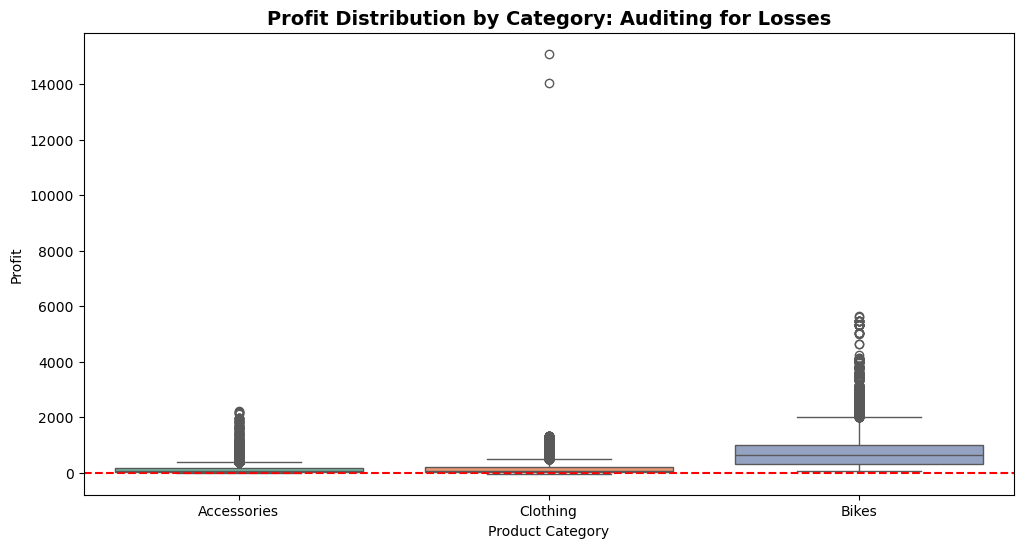

In [10]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=sales_data, x='Product Category', y='Profit', 
            hue='Product Category', palette='Set2', legend=False)

plt.title('Profit Distribution by Category: Auditing for Losses', fontsize=14, fontweight='bold')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Break-even Line')

plt.savefig('profit_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. Country Performance: Revenue vs. Margin (Scatter Plot)

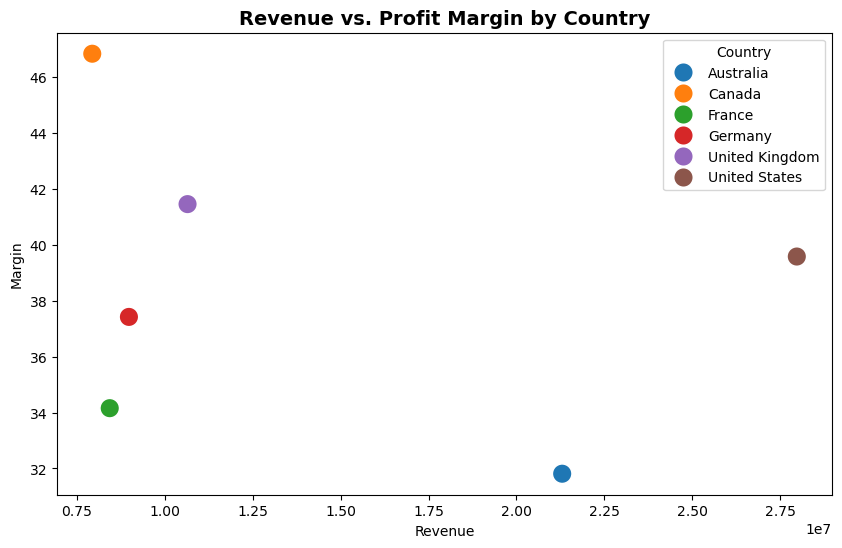

In [11]:
# Grouping by country for the plot
country_stats = sales_data.groupby('Country').agg({'Revenue':'sum', 'Profit':'sum'})
country_stats['Margin'] = (country_stats['Profit'] / country_stats['Revenue']) * 100

plt.figure(figsize=(10, 6))
sns.scatterplot(data=country_stats, x='Revenue', y='Margin', hue='Country', s=200)
plt.title('Revenue vs. Profit Margin by Country', fontsize=14, fontweight='bold')
plt.savefig('country_performance.png')

## 3. Monthly Trends (Line Chart)

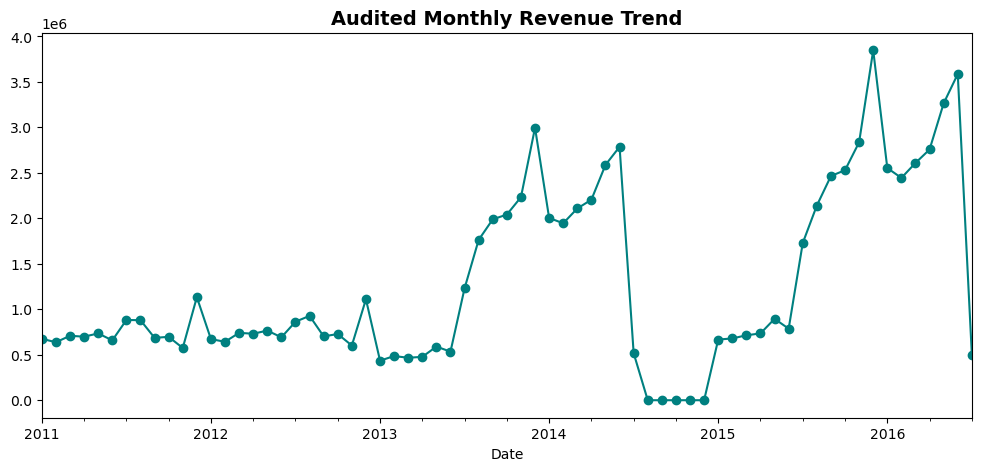

In [12]:
# Date column is converted to datetime first
sales_data['Date'] = pd.to_datetime(sales_data['Date'])
monthly_sales = sales_data.resample('ME', on='Date')['Revenue'].sum()

plt.figure(figsize=(12, 5))
monthly_sales.plot(kind='line', marker='o', color='teal')
plt.title('Audited Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.savefig('monthly_trends.png')